In [1]:
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import nrgpy
from os import getenv
import pandas as pd
from pathlib import Path
from se_analysis import download, channel_names, export_days, rename_channels
from se_analysis.validation import expected_periods, availability
from se_analysis.plot import plot_signals, plot_together

In [2]:
load_dotenv()
client_id = getenv("CLIENT_ID")
client_secret = getenv("CLIENT_SECRET")

In [3]:
sites = nrgpy.CloudSites(client_id=client_id, client_secret=client_secret)
sites.sites_df

2026-08-28 07:47:05,326 | INFO | [sites:59] | 135 sites found


,siteId,siteType,siteNumber,siteDescription,project,loggerSerialNumber,siteRole,longitude,latitude,elevation,fromDateUtc,toDateUtc,loggerType,isActive
0,2359,2,140,NRG NEER SRA,Chugwater Solar,820615692,Admin,-104.655022,41.740438,1665.0,2024-10-16T15:45:08,2026-08-27T11:30:00,SymphoniePRO,True
1,3722,1,851,NRG ZX DEMO SITE,NRG DEMO SITES,851,NaN,-73.624790,45.221420,NaN,2026-07-29T05:00:00,2026-08-28T04:50:00,ZX300,True
2,3748,2,3218,Boralex,Two Rivers SRA,820613217,Admin,-74.741163,44.922468,66.0,2025-06-18T22:30:00,2026-08-27T12:13:00,SymphoniePRO,True
3,3786,2,1255,1255,Caloosahatchee Solar,943101255,Admin,-81.186020,26.745930,9.0,2025-01-11T00:00:00,2026-08-26T23:59:00,LOGR | Solar,True
4,3787,2,910,0910,Caloosahatchee Solar,943100910,Admin,-81.186020,26.745930,9.0,2024-02-06T00:01:00,2026-08-28T00:00:00,LOGR | Solar,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,4649,2,3276,MET#2 INV-1302,Indrio Solar Energy Center,943203276,Admin,-80.529900,27.532500,5.0,NaN,NaN,LOGR | Solar,True
131,4650,2,3278,MET#1 INV-1101,"Wood Stork,FL",943203278,Admin,-80.671716,27.531306,7.0,NaN,NaN,LOGR | Solar,True
132,4651,2,3280,MET#2 INV-1403,"Wood Stork,FL",943203280,Admin,-80.671716,27.531306,7.0,NaN,NaN,LOGR | Solar,True
133,4653,2,3282,MET#1 INV-1202,"Spanish Moss,FL",943203282,Admin,-80.565086,27.508422,7.0,NaN,NaN,LOGR | Solar,True


In [4]:
# Pecos Flats
site_id = 4633
start = "2026-08-01"
end = "2026-08-31"
out_dir = download("data", "Pecos Flats")
files = export_days(site_id, start, end, out_dir)

2026-08-28 07:47:05,770 | ERROR | [export:236] | export not created


400 | Bad Request
Invalid Export Job request as no data points exist for the given interval
2026-08-01: export failed


2026-08-28 07:47:06,171 | ERROR | [export:236] | export not created


400 | Bad Request
Invalid Export Job request as no data points exist for the given interval
2026-08-02: export failed


2026-08-28 07:47:06,572 | ERROR | [export:236] | export not created


...

400 | Bad Request
Invalid Export Job request as no data points exist for the given interval
2026-08-29: export failed


2026-08-28 07:47:10,254 | ERROR | [export:236] | export not created


400 | Bad Request
Invalid Export Job request as no data points exist for the given interval
2026-08-30: export failed


2026-08-28 07:47:10,720 | ERROR | [export:236] | export not created


400 | Bad Request
Invalid Export Job request as no data points exist for the given interval
2026-08-31: export failed


In [5]:
reader = nrgpy.SymProTextRead()
reader.concat_txt(str(out_dir))

Time elapsed: 0 s | 18  / 18  [=============================================] 100%	



In [6]:
reader.Site_info

,0,1
0,Export Assembly Version:,1.0.0.148
1,Export version:,3
2,Generated:,2026-08-27 10:54:06
3,Export Parameters,NaN
4,Site Number:,000680
...,...,...
549,Units:,Ratio
550,Math Function:,Albedo
551,RHI Channel:,39
552,GHI Channel:,33


In [7]:
reader.data

,Timestamp,Ch1_Anem_2.06m_NE_Avg_m/s,Ch1_Anem_2.06m_NE_SD_m/s,Ch1_Anem_2.06m_NE_Min_m/s,Ch1_Anem_2.06m_NE_Max_m/s,Ch1_Anem_2.06m_NE_Gust_m/s,Ch4_Total_1.23m_E_Sum_mm,Ch7_Total_0.00m_W_Sum_mm,Ch13_Vane_2.06m_NW_Avg_Deg,Ch13_Vane_2.06m_NW_SD_Deg,...,Ch101_Calculated___Min_Degrees,Ch101_Calculated___Max_Degrees,Ch102_Calculated___Avg_Ratio,Ch102_Calculated___SD_Ratio,Ch102_Calculated___Min_Ratio,Ch102_Calculated___Max_Ratio,Ch103_Calculated___Avg_Ratio,Ch103_Calculated___SD_Ratio,Ch103_Calculated___Min_Ratio,Ch103_Calculated___Max_Ratio
0,2026-08-05 00:00:00,3.601250,0.556920,2.645,4.940,4.42745,0.0,0.0,137.70,10.12,...,341.38,341.68,502.82,0.21,502.40,503.33,2.26,0.06,2.25,2.5
1,2026-08-05 00:01:00,3.371750,0.604350,1.880,4.940,4.42745,0.0,0.0,139.18,14.11,...,341.68,341.97,502.28,0.23,501.84,502.75,2.50,0.00,2.50,2.5
2,2026-08-05 00:02:00,3.855995,0.748935,2.645,5.705,5.45255,0.0,0.0,136.21,13.88,...,341.98,342.28,501.89,0.19,501.49,502.25,2.46,0.09,2.25,2.5
3,2026-08-05 00:03:00,3.193505,0.489600,2.645,4.175,3.92255,0.0,0.0,142.17,8.75,...,342.28,342.58,501.52,0.22,501.00,501.93,2.33,0.12,2.25,2.5
4,2026-08-05 00:04:00,3.614255,0.769590,2.645,6.470,5.70500,0.0,0.0,140.82,11.13,...,342.58,342.88,501.23,0.17,500.84,501.59,2.35,0.12,2.25,2.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23247,2026-08-26 03:27:00,2.466755,0.586755,1.115,3.410,3.15755,0.0,0.0,159.89,9.53,...,47.52,47.74,492.17,0.19,491.78,492.62,2.25,0.09,1.80,2.5
23248,2026-08-26 03:28:00,2.937995,0.489600,1.880,4.175,3.66245,0.0,0.0,157.36,9.35,...,47.75,47.97,491.87,0.22,491.29,492.38,2.30,0.13,1.80,2.5
23249,2026-08-26 03:29:00,2.325995,0.585990,1.115,4.175,3.41000,0.0,0.0,159.94,7.08,...,47.98,48.20,491.16,0.31,490.63,491.89,2.33,0.23,2.00,2.5
23250,2026-08-26 03:30:00,2.631995,0.589050,1.115,4.175,3.66245,0.0,0.0,161.89,9.90,...,48.20,48.43,490.84,0.20,490.29,491.30,1.99,0.03,1.80,2.0


In [8]:
names = channel_names(reader.Site_info)
names

{'1': 'Ch1_NRG_40C_Anem_m/s',
 '4': 'Ch4_Rain_Gauge_mm',
 '7': 'Ch7_Clean_Button_mm',
 '13': 'Ch13_NRG_200M_Vane_Deg',
 '14': 'Ch14_NRG_T60_Temp_C',
 '16': 'Ch16_D-T_SPN1_GHI_W/sqm',
 '17': 'Ch17_D-T_SPN1_DIF_W/sqm',
 '18': 'Ch18_NRG_BP65_Baro_hPa',
 '19': 'Ch19_NRG_RH5X_Humi_%RH',
 '20': 'Ch20_Battery_Bank_Volts',
 '21': 'Ch21_NRG_PVT1_Temp_Clean_C',
 '22': 'Ch22_NRG_PVT1_Temp_Soiled_C',
 '23': 'Ch23_PSM_NRG-30W_VocClean_V',
 '24': 'Ch24_PSM_NRG-30W_VocSoil_V',
 '25': 'Ch25_PSM_NRG-30W_IscClean_A',
 '26': 'Ch26_PSM_NRG-30W_IscSoil_A',
 '27': 'Ch27_SR30-Irradiance_Solar_Irradiance_W/m^2',
 '28': 'Ch28_SR30-Temp_Body_Temp_C',
 '29': 'Ch29_SR30-Humidity_Humidity_(RH)_%',
 '30': 'Ch30_SR30-Tilt_Tilt_Angle_Avg_Deg',
 '31': 'Ch31_SR30-Fan_Fan_speed_RPM',
 '32': 'Ch32_SR30-Heater_Heater_Current_mA',
 '33': 'Ch33_SR30-Irradiance_Solar_Irradiance_W/m^2',
 '34': 'Ch34_SR30-Temp_Body_Temp_C',
 '35': 'Ch35_SR30-Humidity_Humidity_(RH)_%',
 '36': 'Ch36_SR30-Tilt_Tilt_Angle_Avg_Deg',
 '37': 'Ch37_SR

In [9]:
df = reader.data
df = rename_channels(df, names)
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.set_index("Timestamp")
df

,Ch1_Avg_NRG_40C_Anem_m/s,Ch1_SD_NRG_40C_Anem_m/s,Ch1_Min_NRG_40C_Anem_m/s,Ch1_Max_NRG_40C_Anem_m/s,Ch1_Gust_NRG_40C_Anem_m/s,Ch4_Rain_Gauge_mm,Ch7_Clean_Button_mm,Ch13_Avg_NRG_200M_Vane_Deg,Ch13_SD_NRG_200M_Vane_Deg,Ch13_GustDir_NRG_200M_Vane_Deg,...,Ch101_Min_Solar_Azimuth_Angle_Degrees,Ch101_Max_Solar_Azimuth_Angle_Degrees,Ch102_Avg_Soiling_Ratio_Ratio,Ch102_SD_Soiling_Ratio_Ratio,Ch102_Min_Soiling_Ratio_Ratio,Ch102_Max_Soiling_Ratio_Ratio,Ch103_Avg_Albedo_Ratio,Ch103_SD_Albedo_Ratio,Ch103_Min_Albedo_Ratio,Ch103_Max_Albedo_Ratio
Timestamp,,,,,,,,,,,,,,,,,,,,,
2026-08-05 00:00:00,3.601250,0.556920,2.645,4.940,4.42745,0.0,0.0,137.70,10.12,139.11,...,341.38,341.68,502.82,0.21,502.40,503.33,2.26,0.06,2.25,2.5
2026-08-05 00:01:00,3.371750,0.604350,1.880,4.940,4.42745,0.0,0.0,139.18,14.11,126.67,...,341.68,341.97,502.28,0.23,501.84,502.75,2.50,0.00,2.50,2.5
2026-08-05 00:02:00,3.855995,0.748935,2.645,5.705,5.45255,0.0,0.0,136.21,13.88,141.29,...,341.98,342.28,501.89,0.19,501.49,502.25,2.46,0.09,2.25,2.5
2026-08-05 00:03:00,3.193505,0.489600,2.645,4.175,3.92255,0.0,0.0,142.17,8.75,144.43,...,342.28,342.58,501.52,0.22,501.00,501.93,2.33,0.12,2.25,2.5
2026-08-05 00:04:00,3.614255,0.769590,2.645,6.470,5.70500,0.0,0.0,140.82,11.13,149.88,...,342.58,342.88,501.23,0.17,500.84,501.59,2.35,0.12,2.25,2.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-26 03:27:00,2.466755,0.586755,1.115,3.410,3.15755,0.0,0.0,159.89,9.53,162.11,...,47.52,47.74,492.17,0.19,491.78,492.62,2.25,0.09,1.80,2.5
2026-08-26 03:28:00,2.937995,0.489600,1.880,4.175,3.66245,0.0,0.0,157.36,9.35,151.41,...,47.75,47.97,491.87,0.22,491.29,492.38,2.30,0.13,1.80,2.5
2026-08-26 03:29:00,2.325995,0.585990,1.115,4.175,3.41000,0.0,0.0,159.94,7.08,166.41,...,47.98,48.20,491.16,0.31,490.63,491.89,2.33,0.23,2.00,2.5


In [10]:
expected = expected_periods(start, end, pd.Timedelta("1 minute"))
expected

44640

In [11]:
result = availability(start, end, df)
result

(52.087813620071685,
                 start                 end        duration  n_missing
 0 2026-08-01 00:00:00 2026-08-05 00:00:00 4 days 00:00:00       5760
 1 2026-08-07 03:32:00 2026-08-12 03:32:00 5 days 00:00:00       7200
 2 2026-08-26 03:32:00 2026-09-01 00:00:00 5 days 20:28:00       8428)

In [12]:
for col in df.columns:
    print(col)

Ch1_Avg_NRG_40C_Anem_m/s
Ch1_SD_NRG_40C_Anem_m/s
Ch1_Min_NRG_40C_Anem_m/s
Ch1_Max_NRG_40C_Anem_m/s
Ch1_Gust_NRG_40C_Anem_m/s
Ch4_Rain_Gauge_mm
Ch7_Clean_Button_mm
Ch13_Avg_NRG_200M_Vane_Deg
Ch13_SD_NRG_200M_Vane_Deg
Ch13_GustDir_NRG_200M_Vane_Deg
Ch14_Avg_NRG_T60_Temp_C
Ch14_SD_NRG_T60_Temp_C
Ch14_Min_NRG_T60_Temp_C
Ch14_Max_NRG_T60_Temp_C
Ch16_Avg_D-T_SPN1_GHI_W/sqm
Ch16_SD_D-T_SPN1_GHI_W/sqm
Ch16_Min_D-T_SPN1_GHI_W/sqm
Ch16_Max_D-T_SPN1_GHI_W/sqm
Ch17_Avg_D-T_SPN1_DIF_W/sqm
Ch17_SD_D-T_SPN1_DIF_W/sqm
Ch17_Min_D-T_SPN1_DIF_W/sqm
Ch17_Max_D-T_SPN1_DIF_W/sqm
Ch18_Avg_NRG_BP65_Baro_hPa
Ch18_SD_NRG_BP65_Baro_hPa
Ch18_Min_NRG_BP65_Baro_hPa
Ch18_Max_NRG_BP65_Baro_hPa
Ch19_Avg_NRG_RH5X_Humi_%RH
Ch19_SD_NRG_RH5X_Humi_%RH
Ch19_Min_NRG_RH5X_Humi_%RH
Ch19_Max_NRG_RH5X_Humi_%RH
Ch20_Avg_Battery_Bank_Volts
Ch20_SD_Battery_Bank_Volts
Ch20_Min_Battery_Bank_Volts
Ch20_Max_Battery_Bank_Volts
Ch21_Avg_NRG_PVT1_Temp_Clean_C
Ch21_SD_NRG_PVT1_Temp_Clean_C
Ch21_Min_NRG_PVT1_Temp_Clean_C
Ch21_Max_NRG_PVT1_T

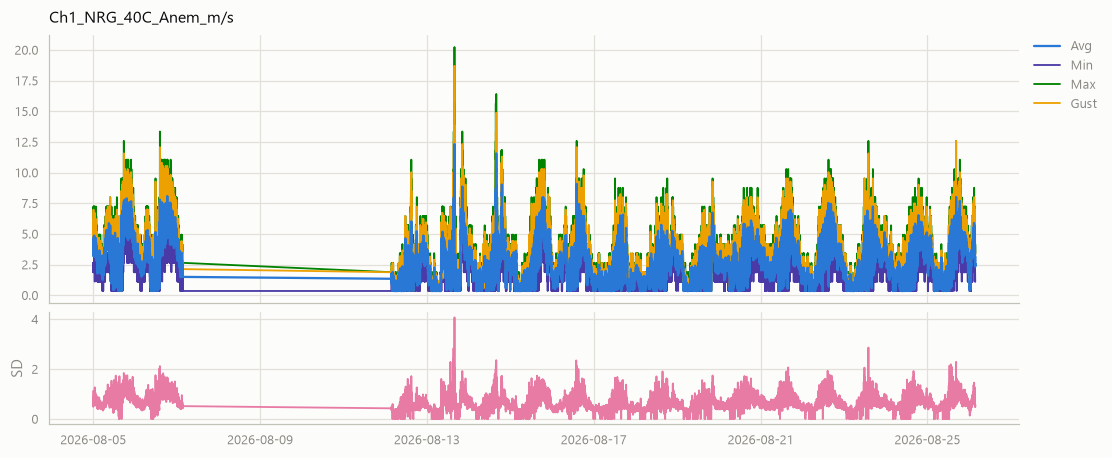

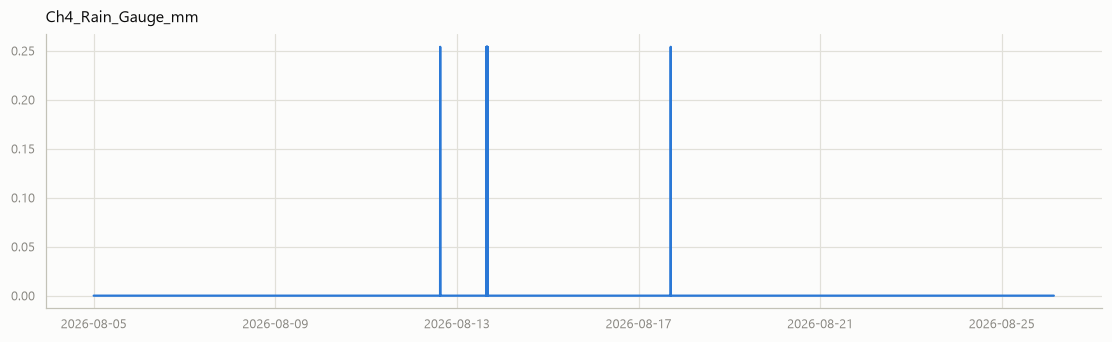

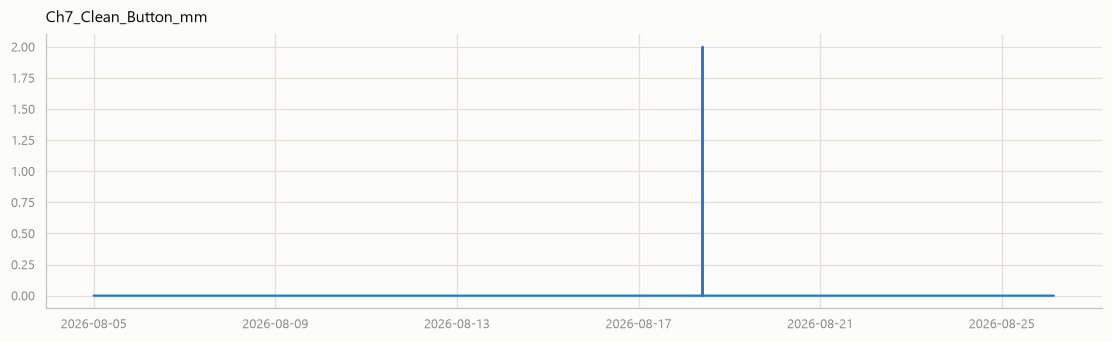

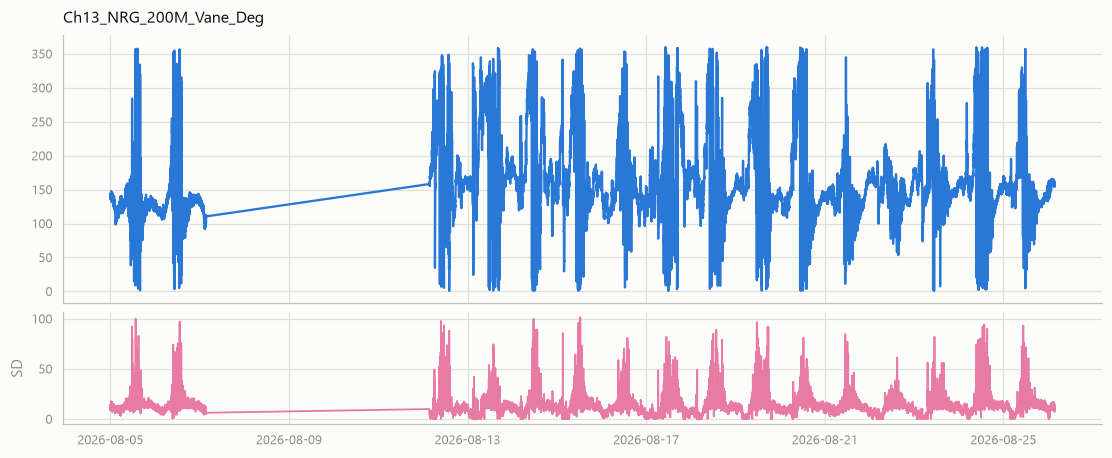

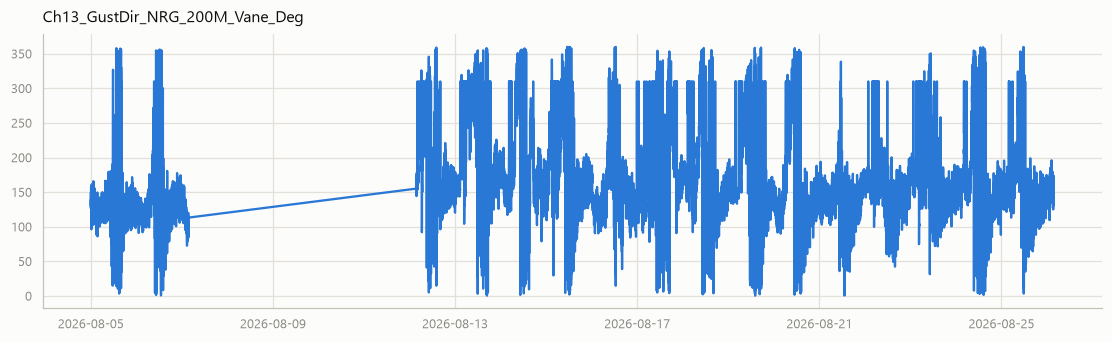

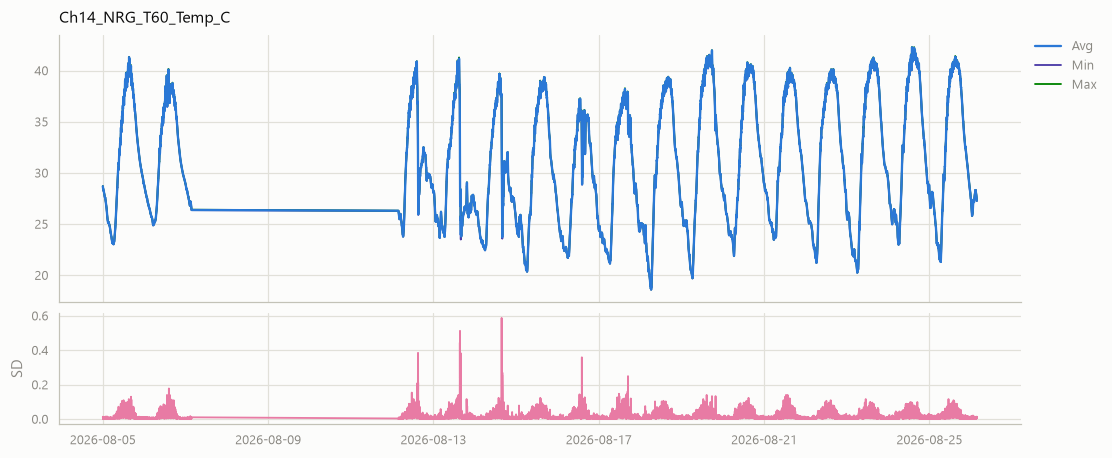

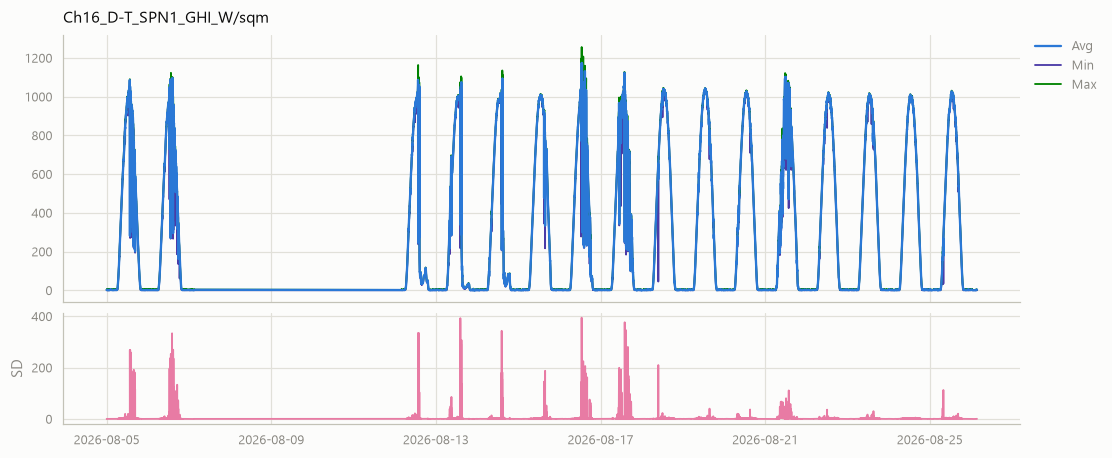

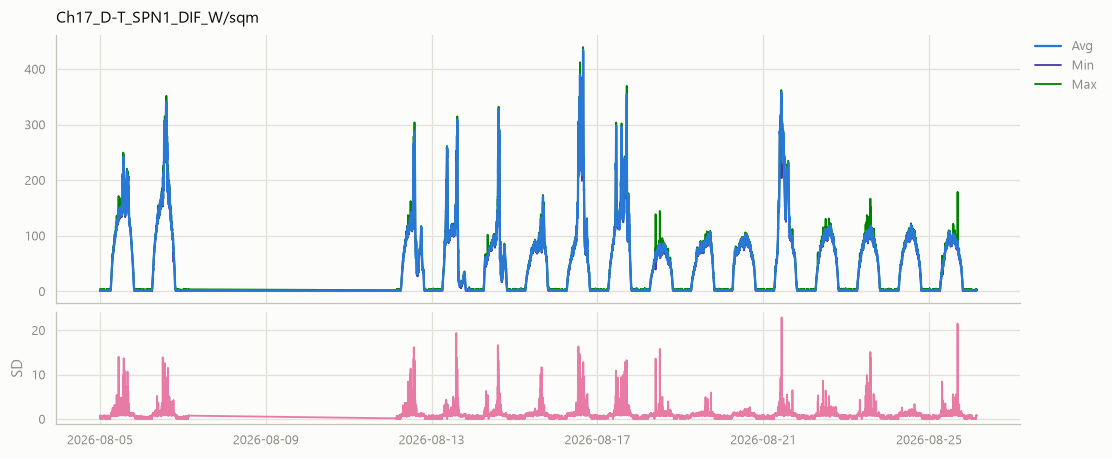

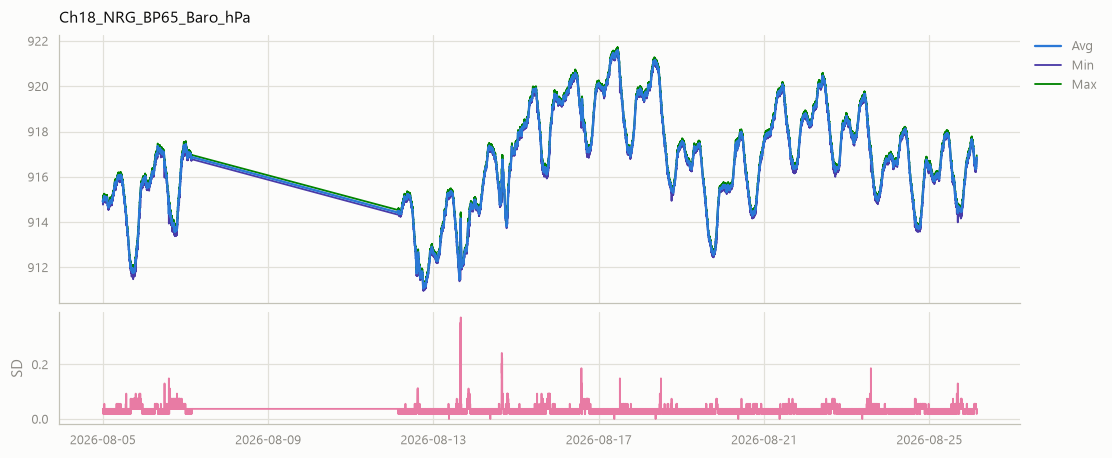

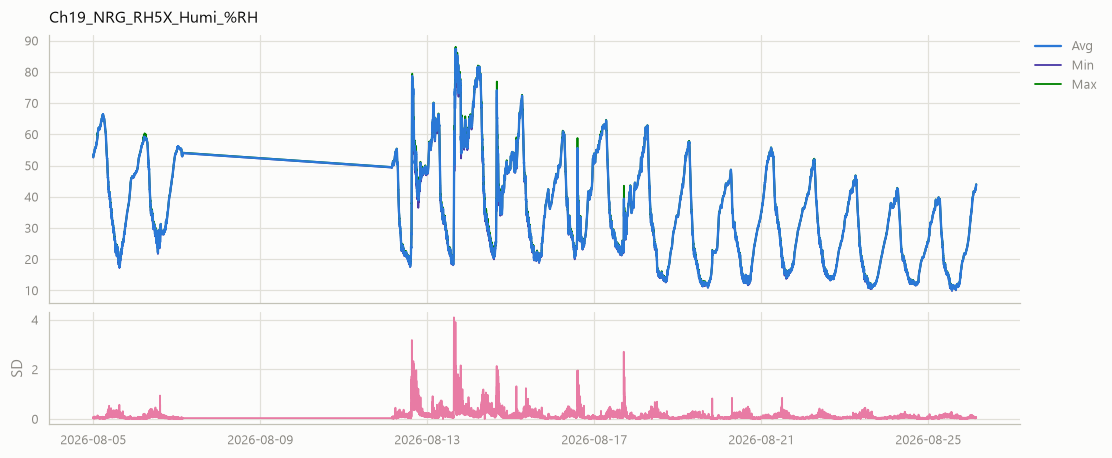

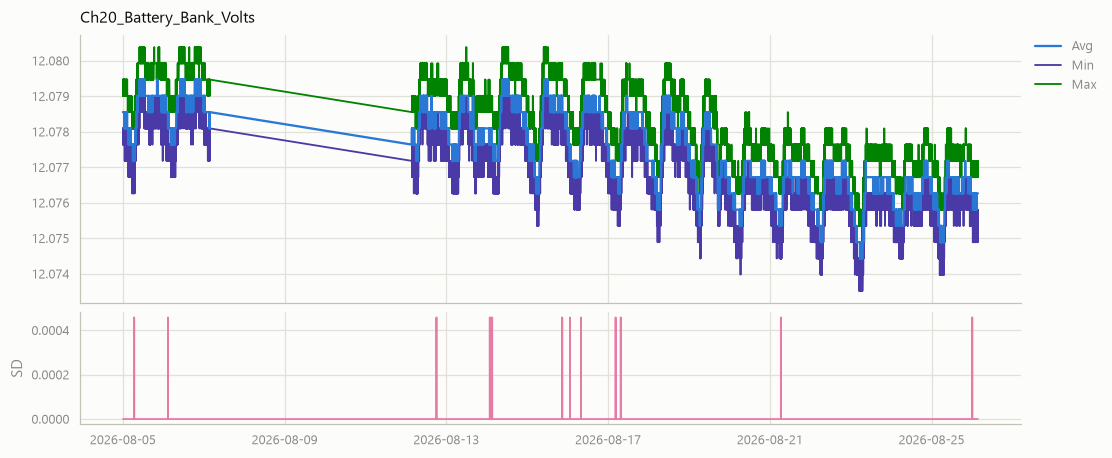

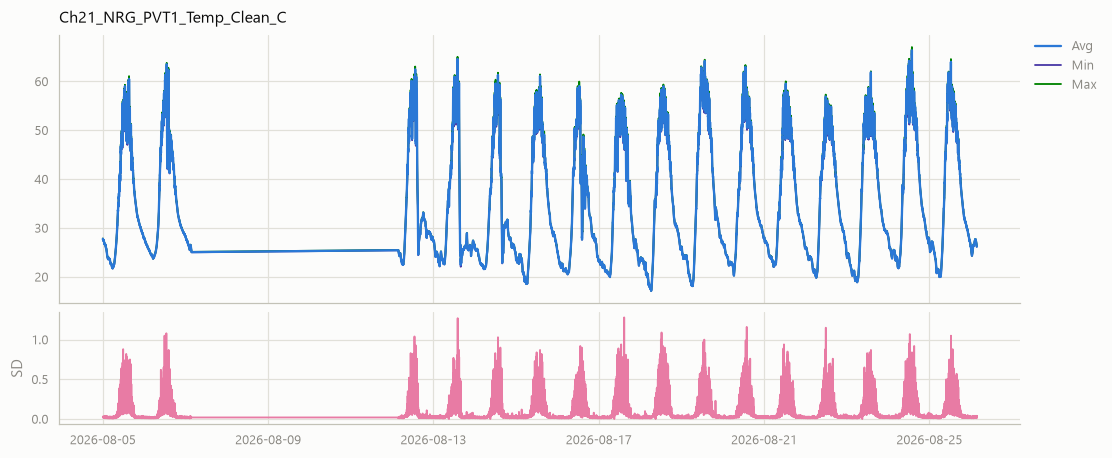

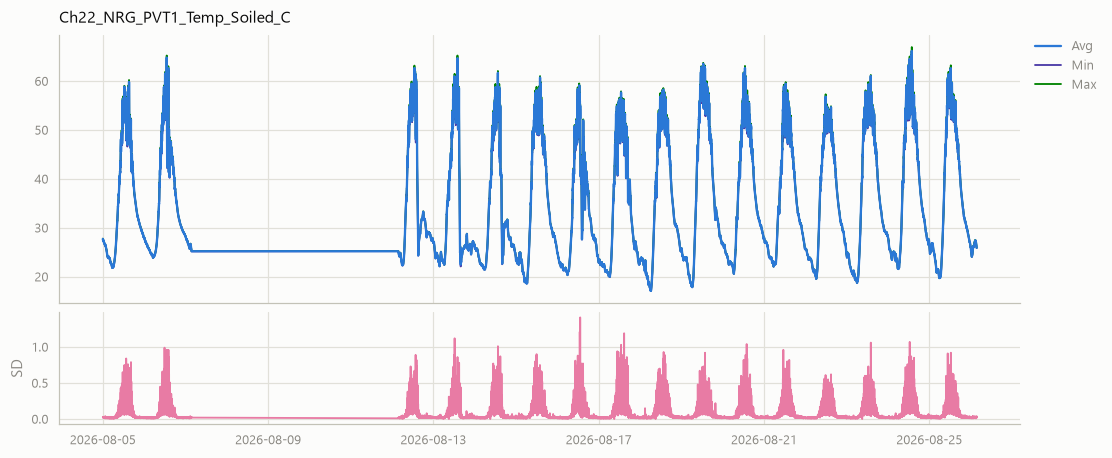

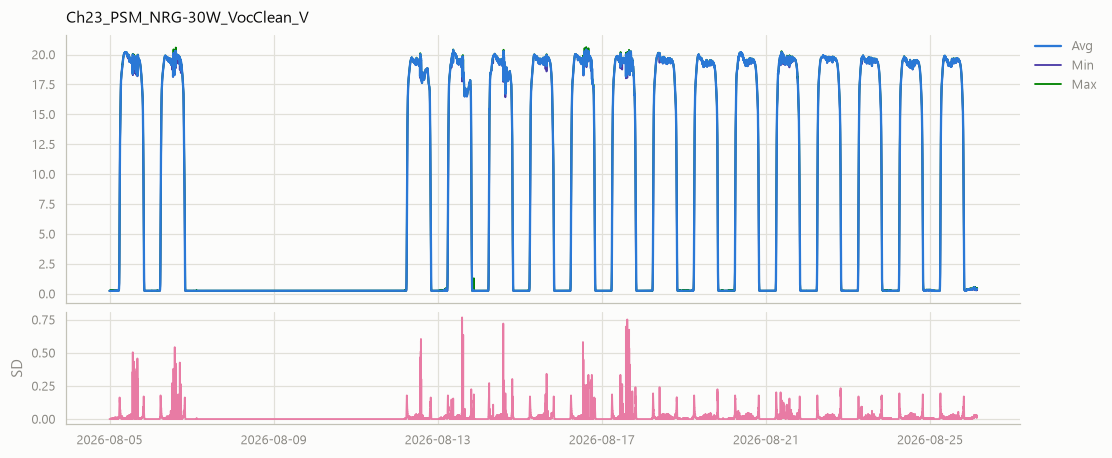

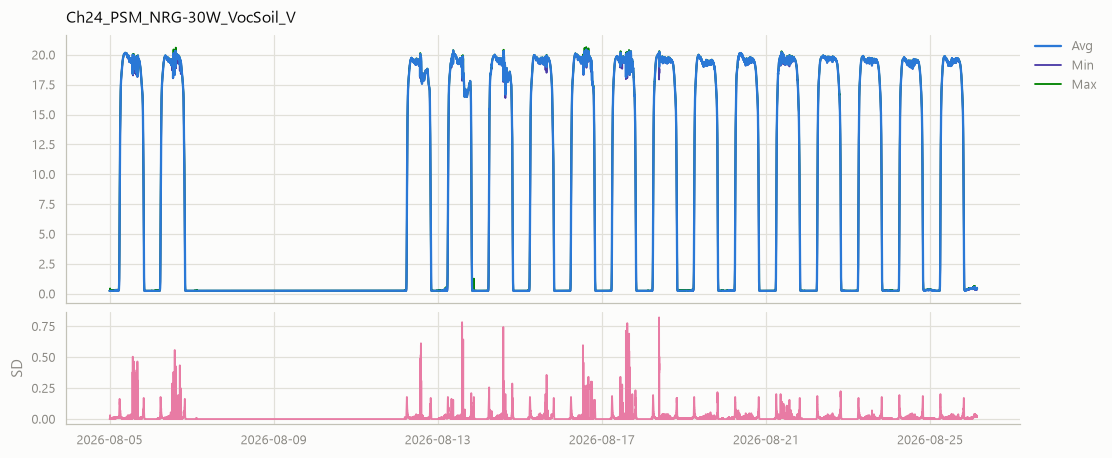

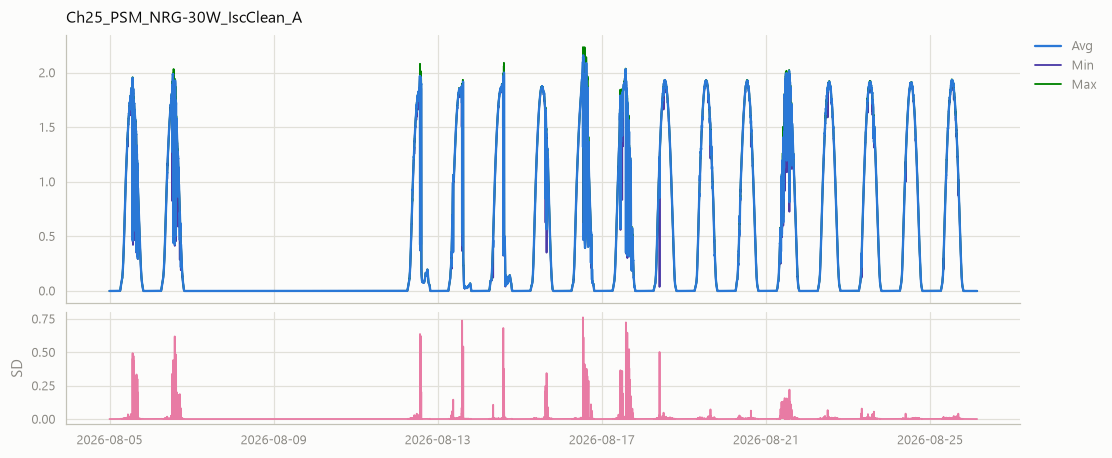

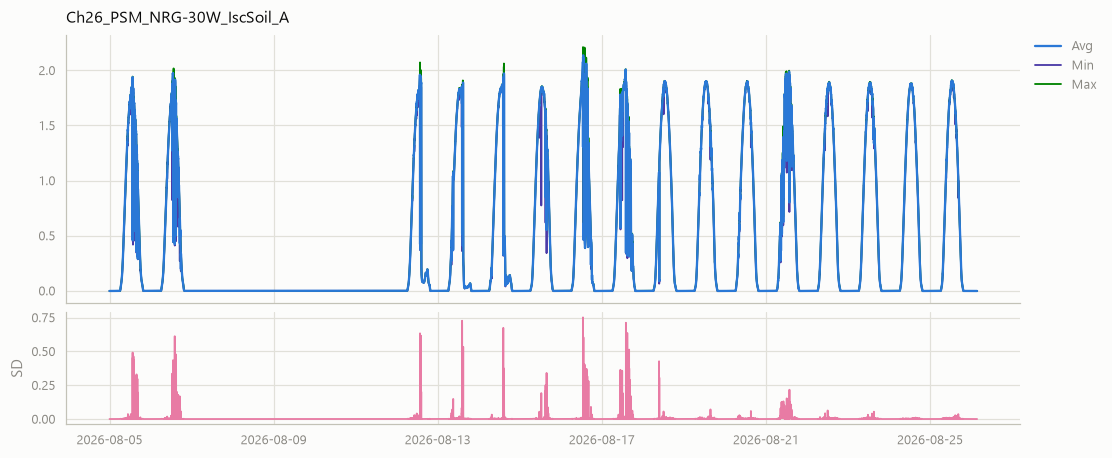

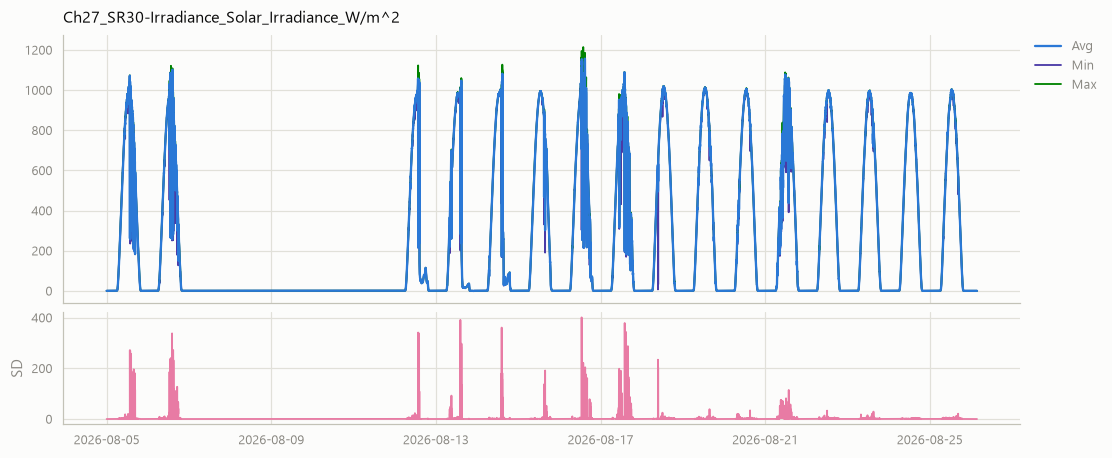

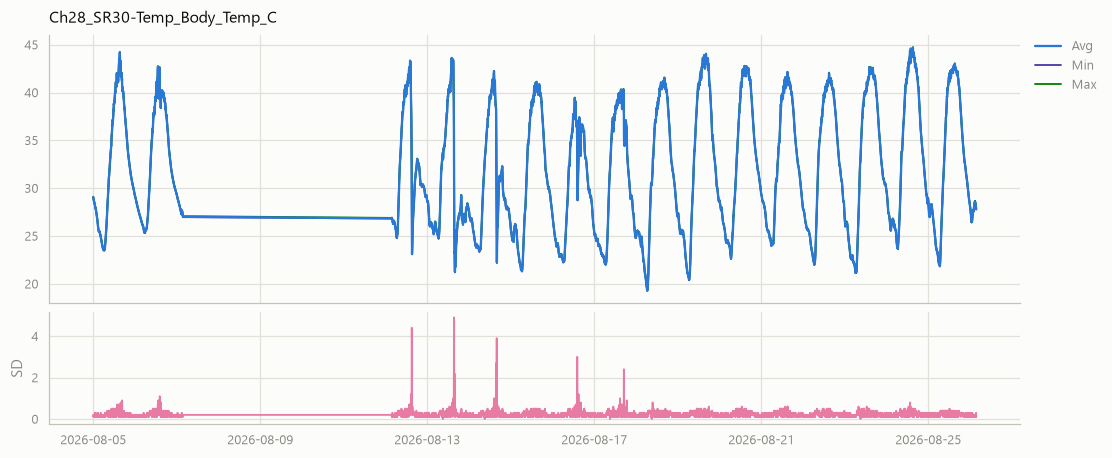

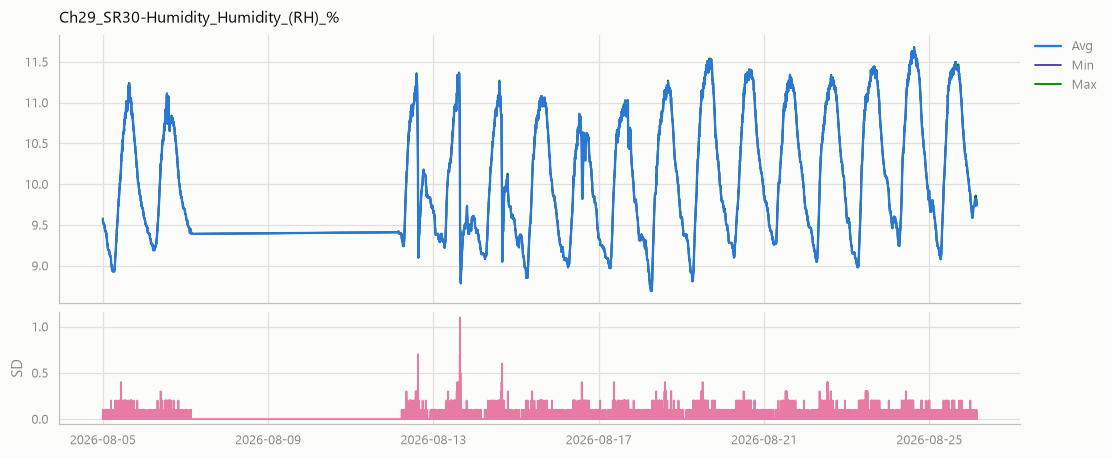

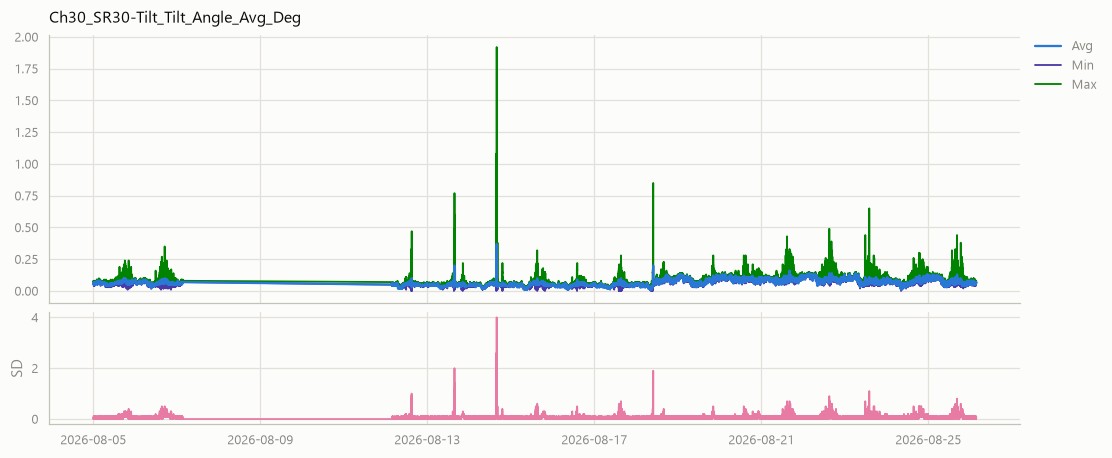

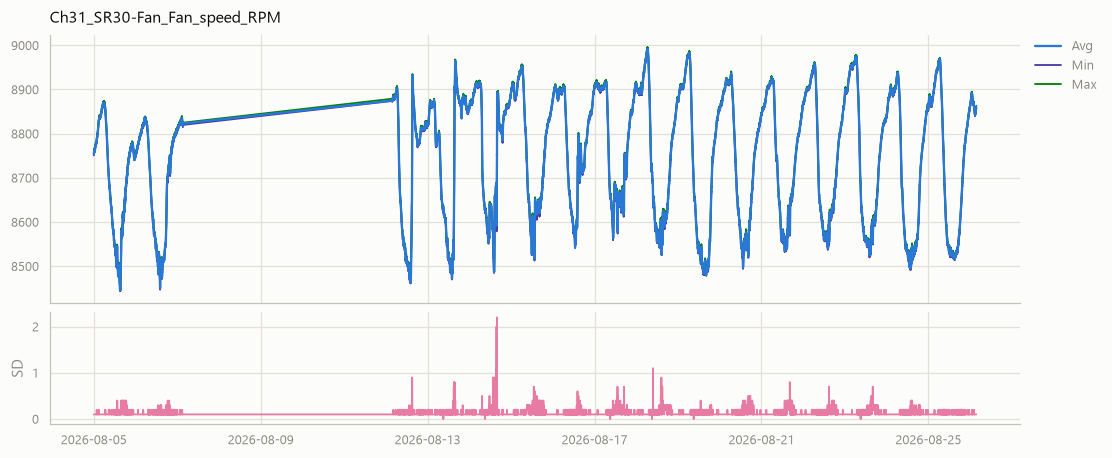

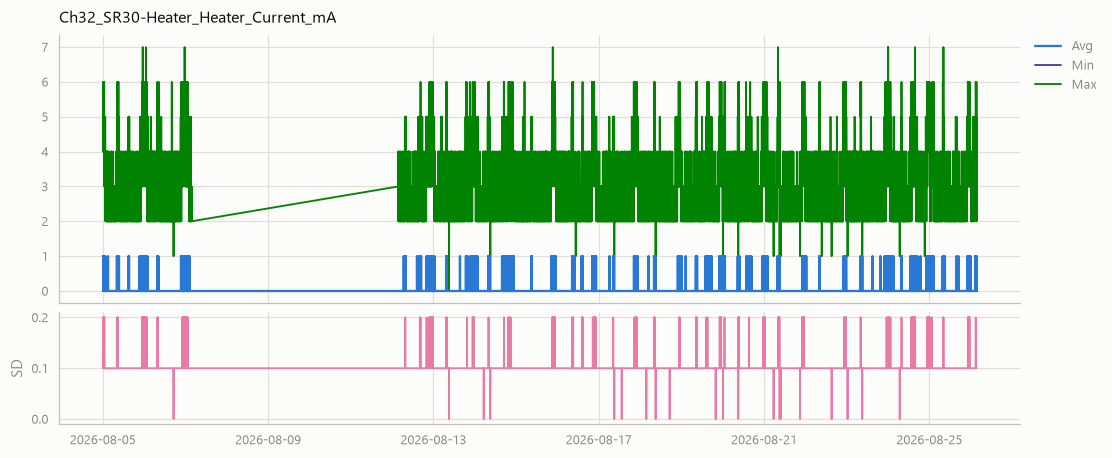

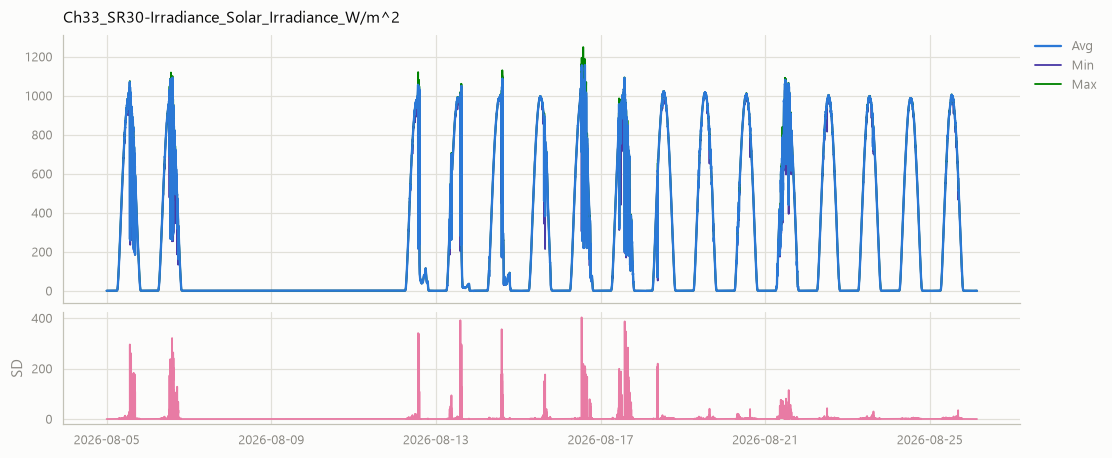

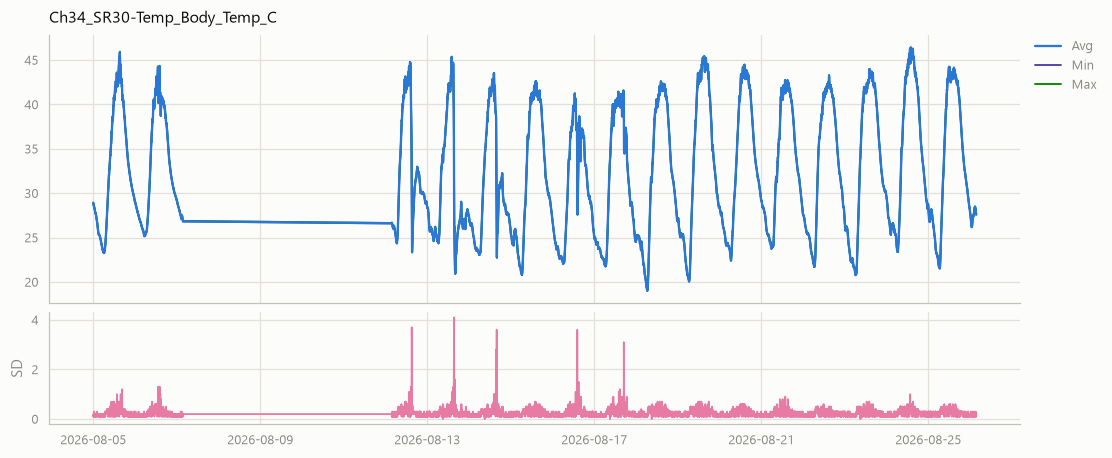

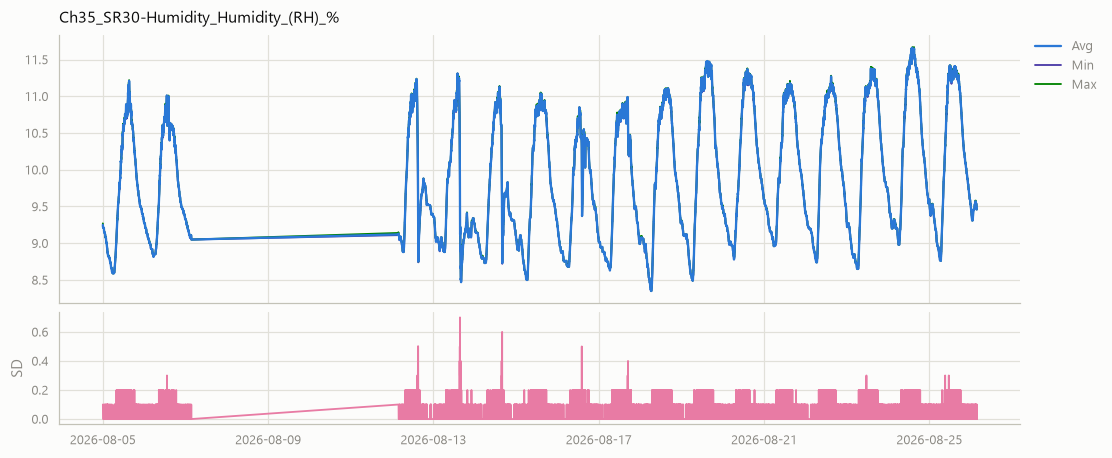

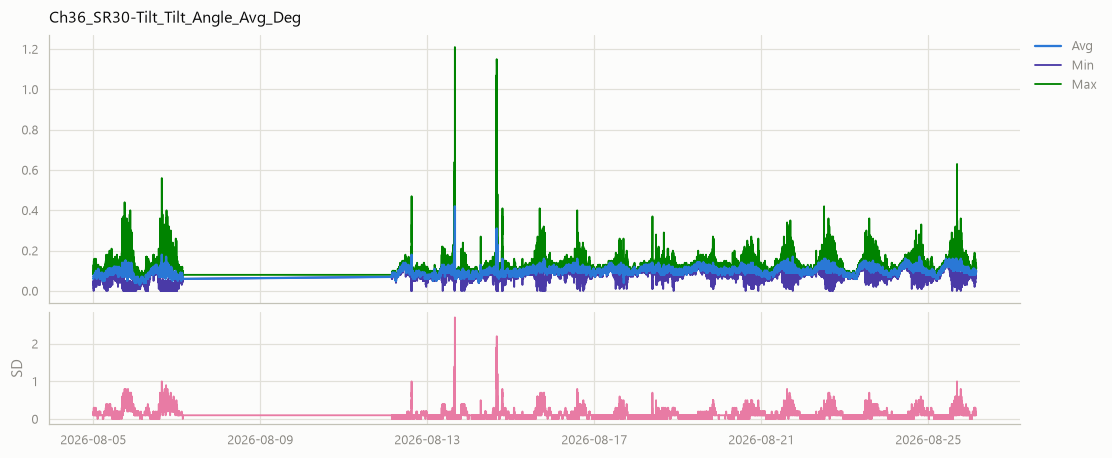

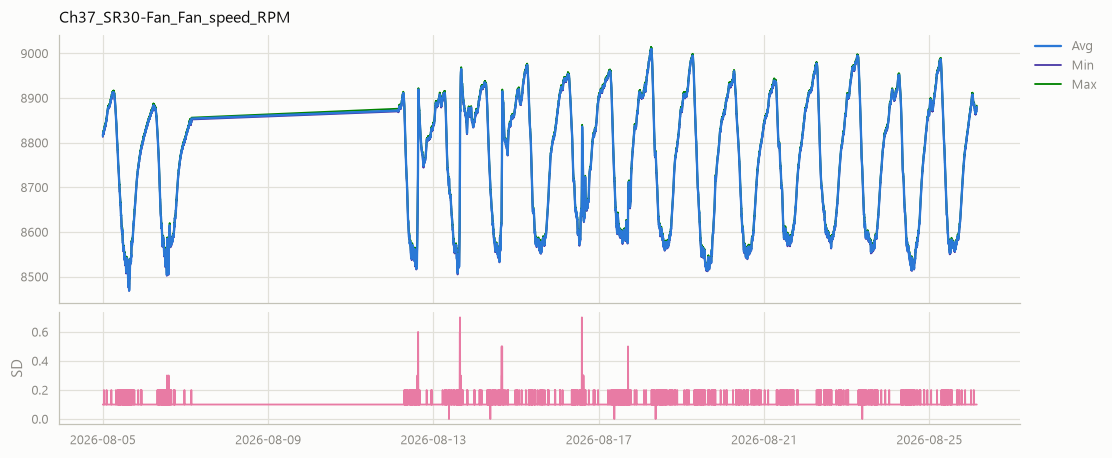

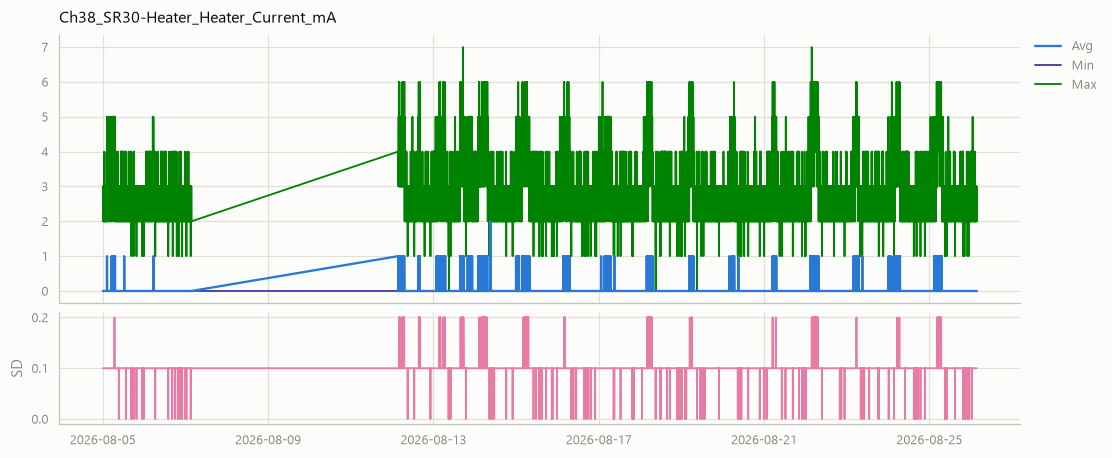

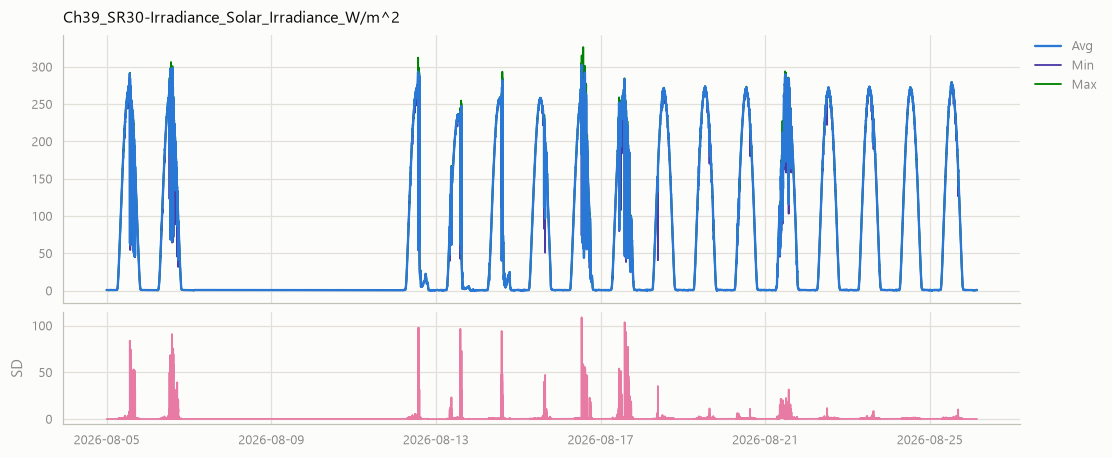

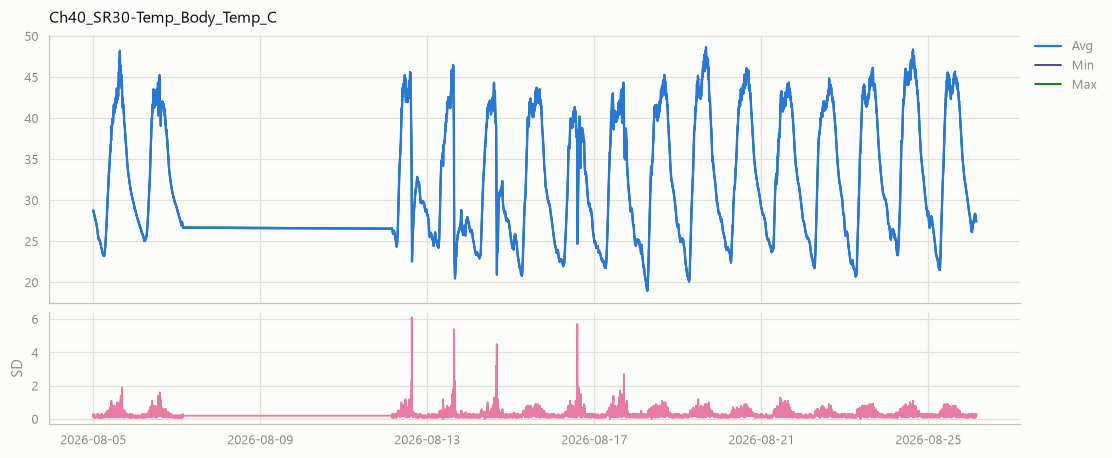

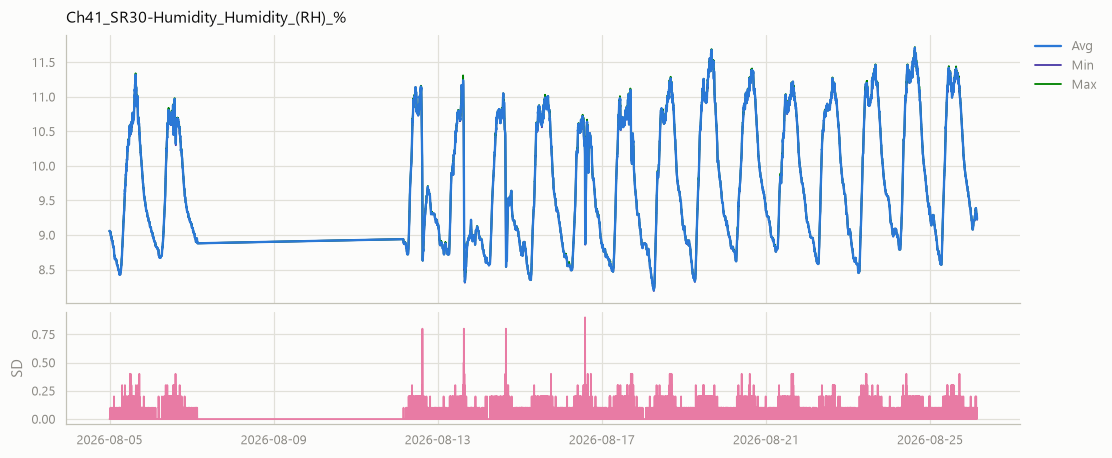

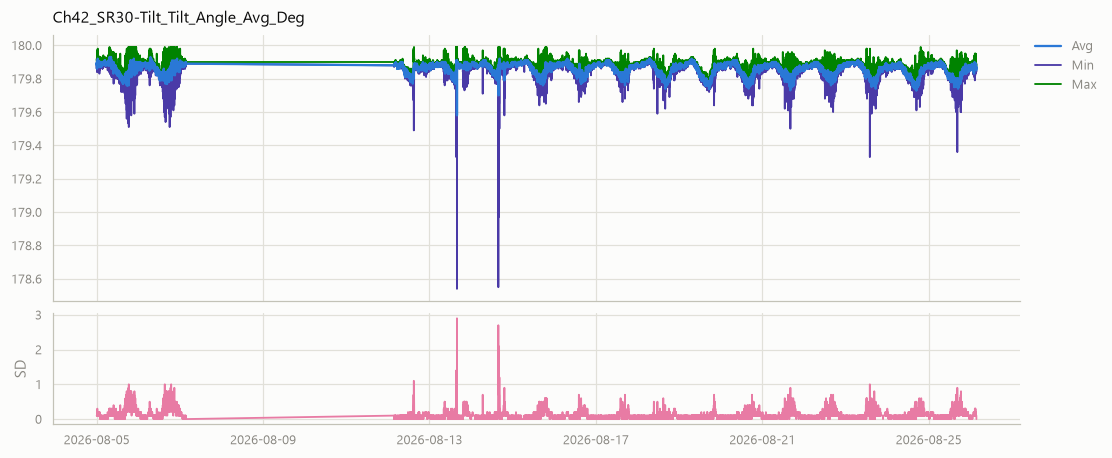

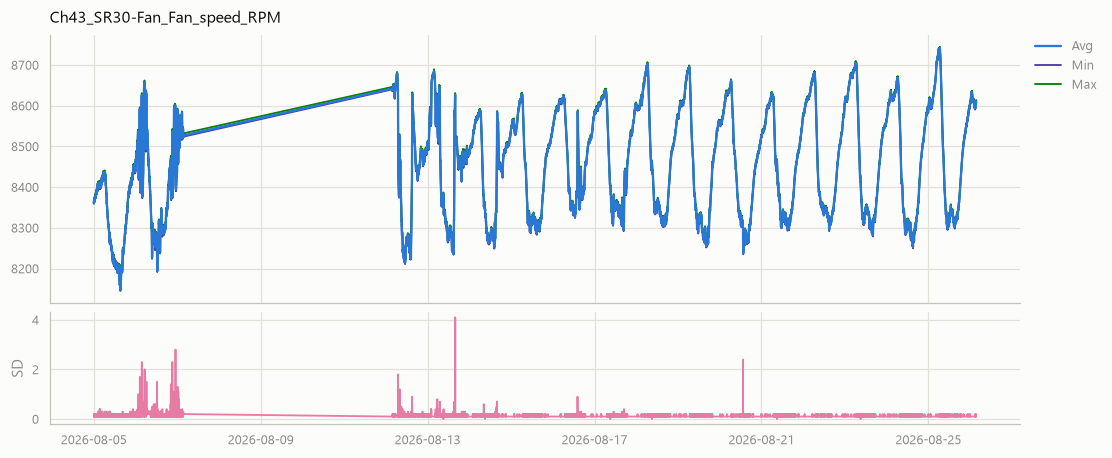

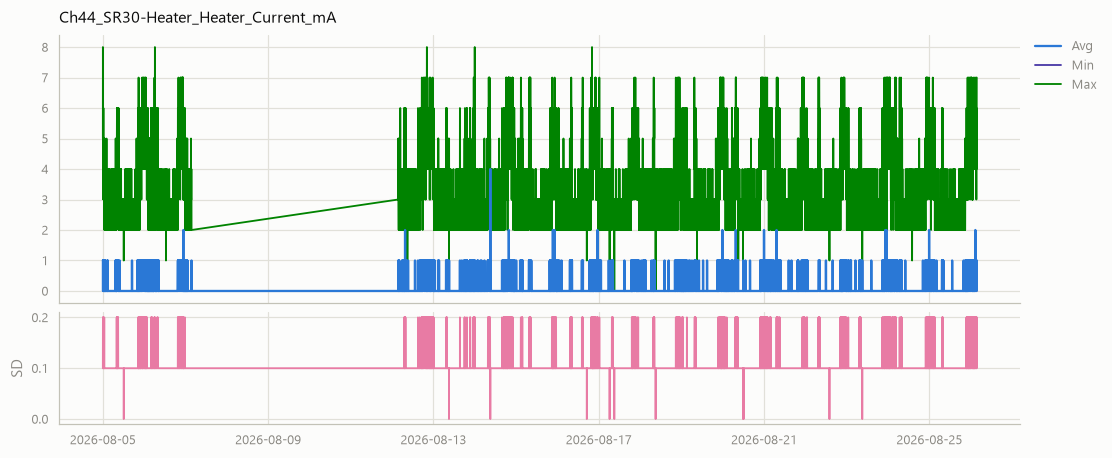

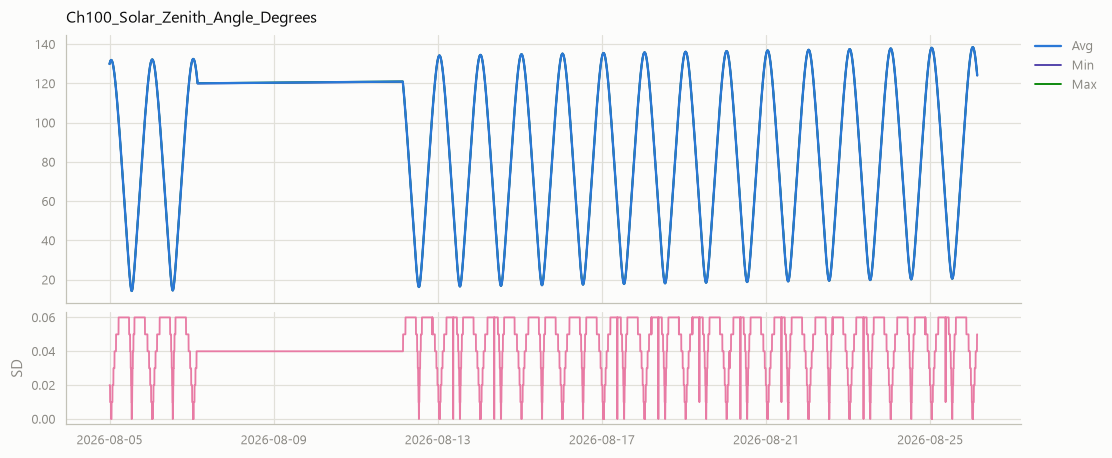

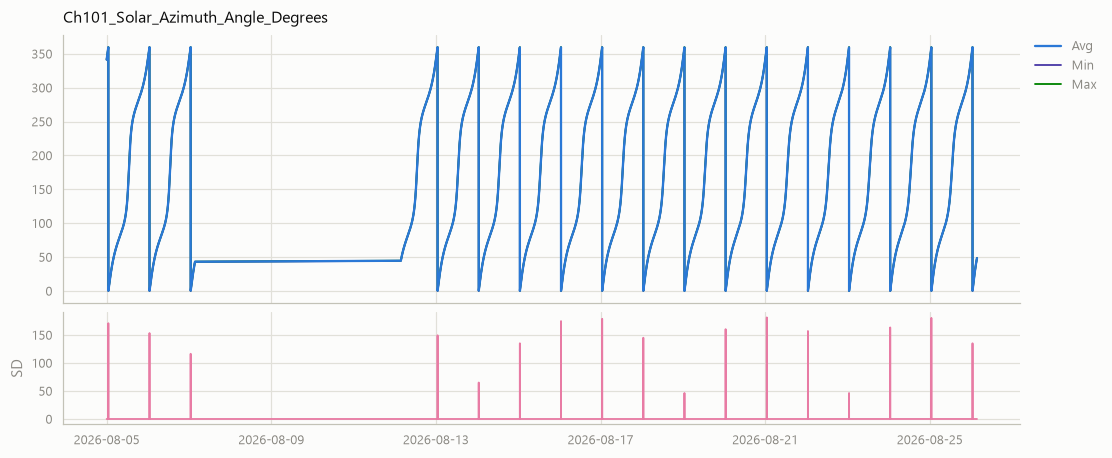

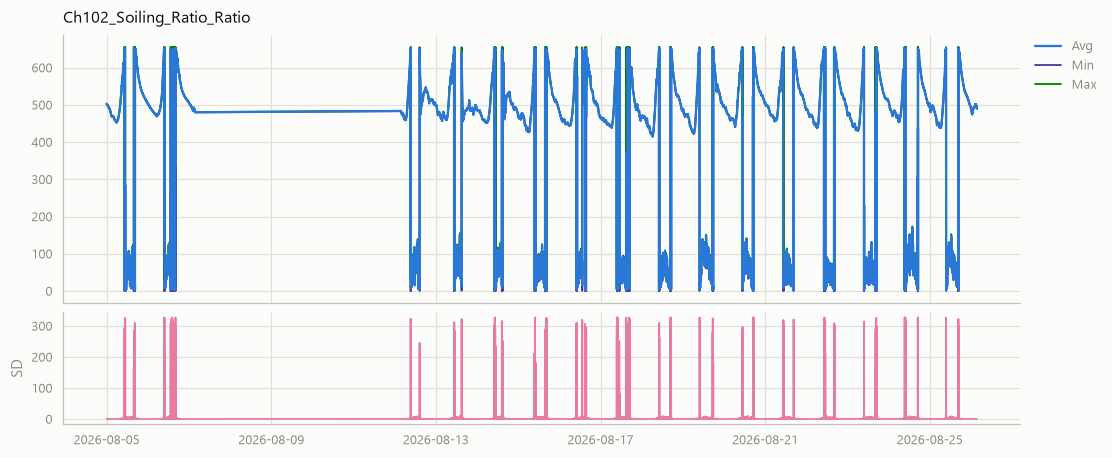

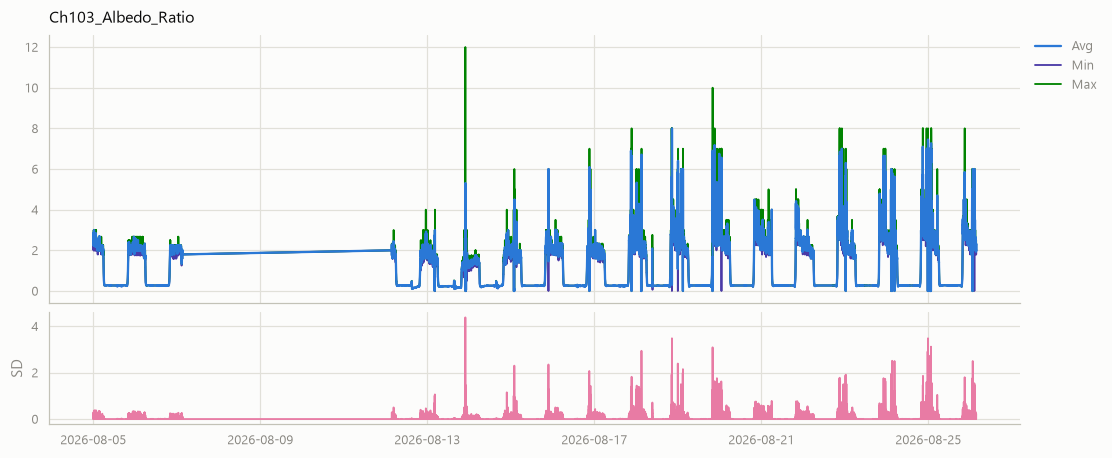

In [13]:
plot_signals(df)

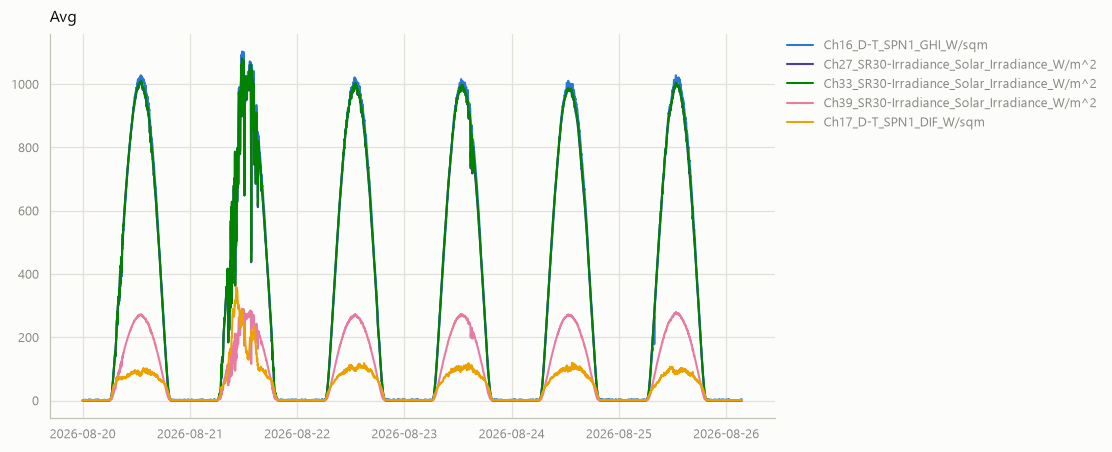

In [17]:
ghi_cols = [
    "Ch16_Avg_D-T_SPN1_GHI_W/sqm",
    "Ch27_Avg_SR30-Irradiance_Solar_Irradiance_W/m^2",
    "Ch33_Avg_SR30-Irradiance_Solar_Irradiance_W/m^2",
    "Ch39_Avg_SR30-Irradiance_Solar_Irradiance_W/m^2",
    "Ch17_Avg_D-T_SPN1_DIF_W/sqm",
]
plot_together(df["2026-08-20":"2026-08-28"], columns=ghi_cols)


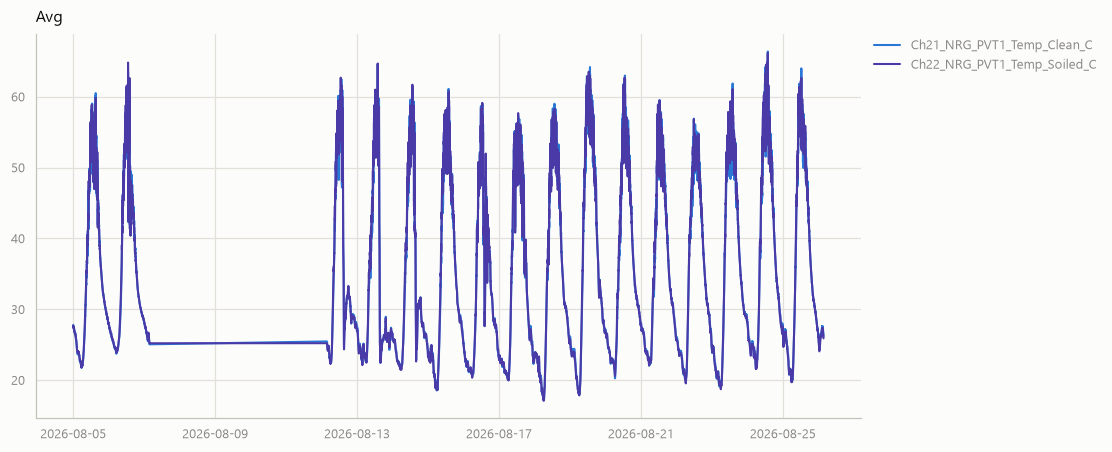

In [18]:
bom_temps = [
    "Ch21_Avg_NRG_PVT1_Temp_Clean_C",
    "Ch22_Avg_NRG_PVT1_Temp_Soiled_C",
]
plot_together(df, columns=bom_temps)

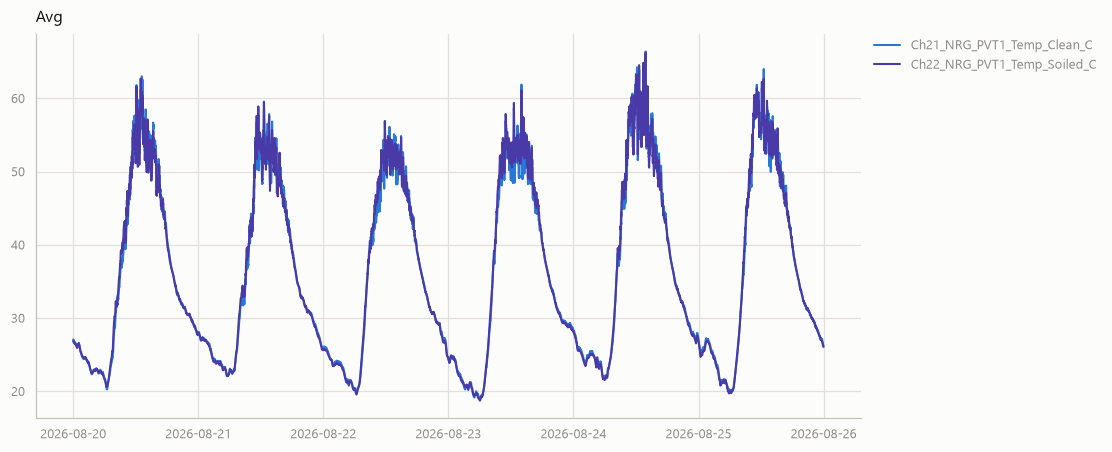

In [24]:
plot_together(df["2026-08-20":"2026-08-25"], columns=bom_temps)

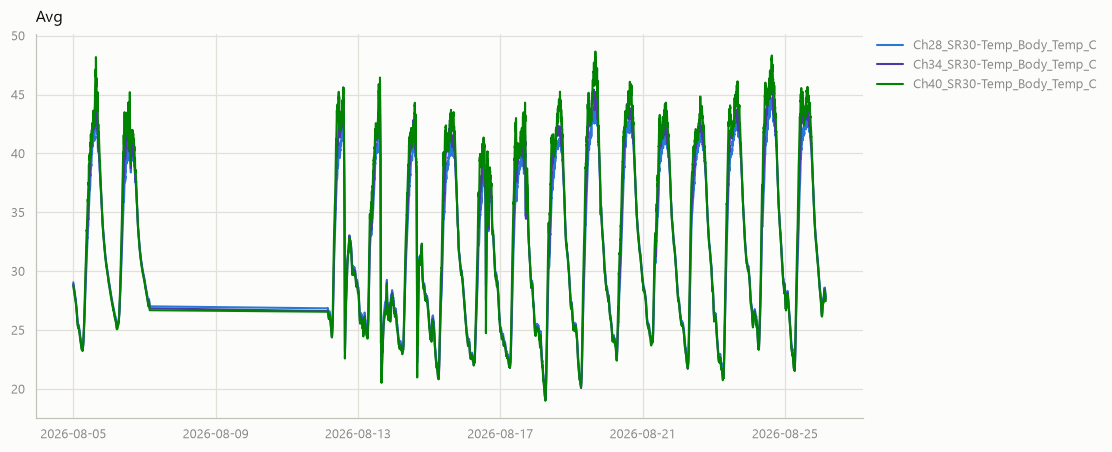

In [26]:
body_temps = [
    "Ch28_Avg_SR30-Temp_Body_Temp_C",
    "Ch34_Avg_SR30-Temp_Body_Temp_C",
    "Ch40_Avg_SR30-Temp_Body_Temp_C",
]
plot_together(df, columns=body_temps)

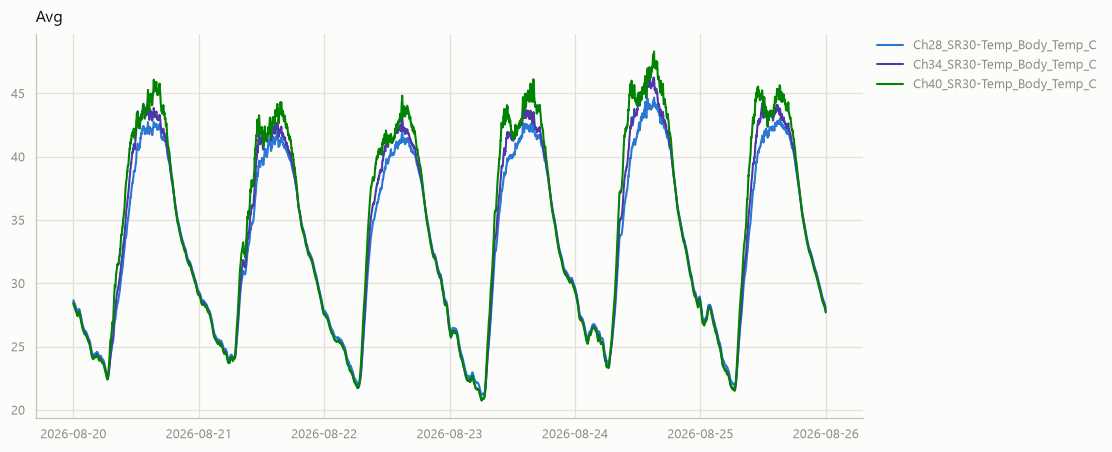

In [25]:
body_temps = [
    "Ch28_Avg_SR30-Temp_Body_Temp_C",
    "Ch34_Avg_SR30-Temp_Body_Temp_C",
    "Ch40_Avg_SR30-Temp_Body_Temp_C",
]
plot_together(df["2026-08-20":"2026-08-25"], columns=body_temps)

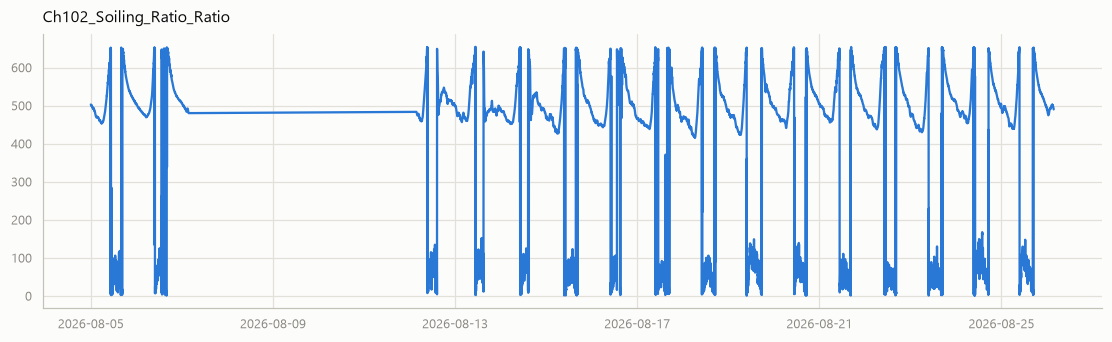

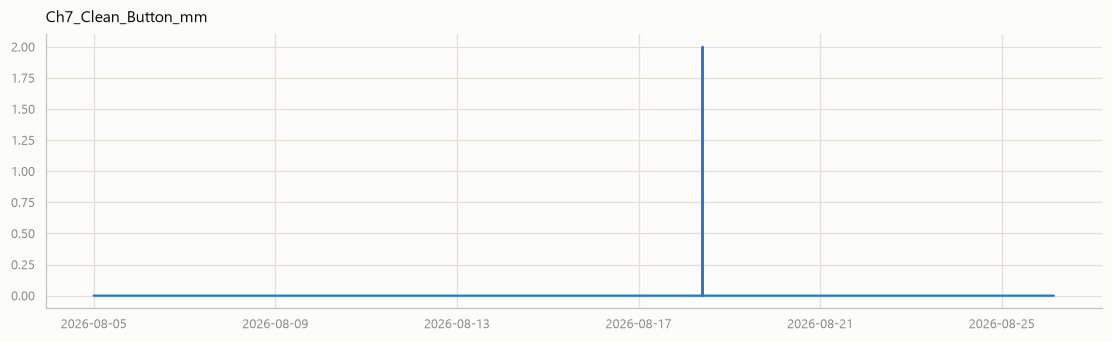

In [32]:
soiling_cols = [
    "Ch102_Avg_Soiling_Ratio_Ratio",
    "Ch7_Clean_Button_mm",
]
plot_signals(df, columns=soiling_cols)

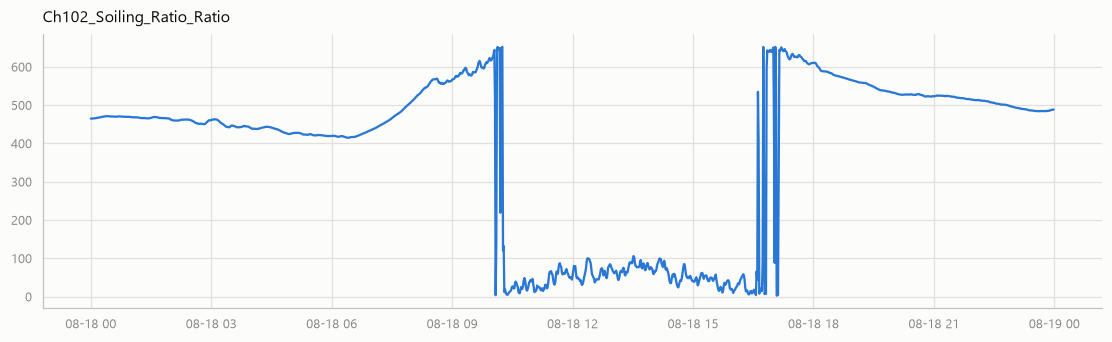

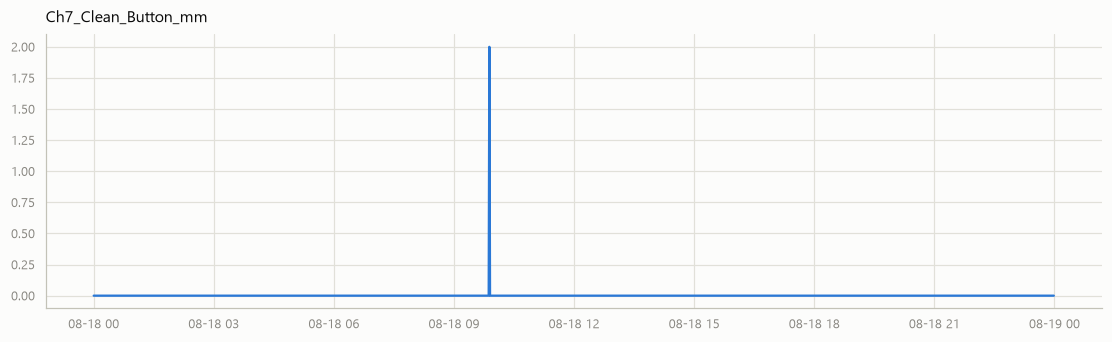

In [35]:
soiling_cols = [
    "Ch102_Avg_Soiling_Ratio_Ratio",
    "Ch7_Clean_Button_mm",
]
plot_signals(df["2026-08-18":"2026-08-18"], columns=soiling_cols)